# Импорт библиотек

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split

from random_forest import CustomRandomForestClassifier, CustomRandomForestRegressor

In [5]:
RANDOM_STATE = 42

# Обучение

In [6]:
iris = load_iris()

In [7]:
X = iris.data[:, :2]
y = iris.target
feature_names = iris.feature_names[:2]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

## Классификация

In [9]:
params_clf = dict(
    n_estimators=80,
    max_depth=6,
    criterion="gini",
    max_features="sqrt",
    random_state=RANDOM_STATE,
)

In [10]:
custom_clf = CustomRandomForestClassifier(**params_clf).fit(X_train, y_train)
sklearn_clf = RandomForestClassifier(
    n_estimators=params_clf["n_estimators"],
    max_depth=params_clf["max_depth"],
    criterion=params_clf["criterion"],
    max_features=params_clf["max_features"],
    bootstrap=True,
    random_state=params_clf["random_state"],
).fit(X_train, y_train)

In [11]:
acc_custom = accuracy_score(y_test, custom_clf.predict(X_test))
acc_sklearn = accuracy_score(y_test, sklearn_clf.predict(X_test))

print(f"Custom accuracy: {acc_custom:.4f}")
print(f"sklearn accuracy: {acc_sklearn:.4f}")

Custom accuracy: 0.6667
sklearn accuracy: 0.7333


In [12]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

In [13]:
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]

In [14]:
Z_custom = custom_clf.predict(grid).reshape(xx.shape)
Z_sklearn = sklearn_clf.predict(grid).reshape(xx.shape)

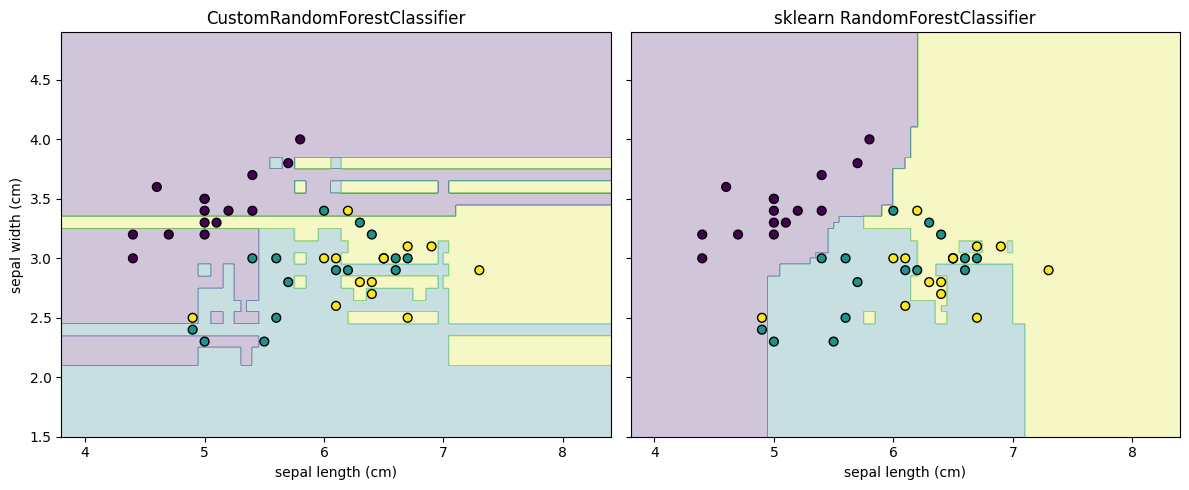

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].contourf(xx, yy, Z_custom, alpha=0.25)
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=40)
axes[0].set_title("CustomRandomForestClassifier")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])

axes[1].contourf(xx, yy, Z_sklearn, alpha=0.25)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=40)
axes[1].set_title("sklearn RandomForestClassifier")
axes[1].set_xlabel(feature_names[0])

plt.tight_layout()
plt.show()

### Важности признаков

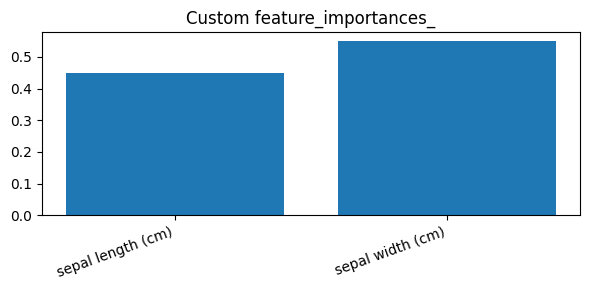

In [16]:
imp = custom_clf.feature_importances_
plt.figure(figsize=(6, 3))
plt.bar(range(len(imp)), imp)
plt.xticks(range(len(imp)), feature_names, rotation=20, ha="right")
plt.title("Custom feature_importances_")
plt.tight_layout()
plt.show()

## Регрессия

In [17]:
ds = fetch_california_housing()
Xr, yr = ds.data, ds.target
feature_names_r = ds.feature_names

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=RANDOM_STATE
)

In [19]:
params_reg = dict(
    n_estimators=120,
    max_depth=None,
    criterion="squared_error",
    max_features=1.0,
    random_state=RANDOM_STATE,
)

In [20]:
custom_reg = CustomRandomForestRegressor(**params_reg).fit(X_train, y_train)
sklearn_reg = RandomForestRegressor(
    n_estimators=params_reg["n_estimators"],
    max_depth=params_reg["max_depth"],
    criterion=params_reg["criterion"],
    max_features=params_reg["max_features"],
    bootstrap=True,
    random_state=params_reg["random_state"],
).fit(X_train, y_train)

In [21]:
pred_custom = custom_reg.predict(X_test)
pred_sklearn = sklearn_reg.predict(X_test)

In [22]:
r2_custom = r2_score(y_test, pred_custom)
r2_sklearn = r2_score(y_test, pred_sklearn)

print(f"Custom R2: {r2_custom:.4f}")
print(f"sklearn R2: {r2_sklearn:.4f}")

Dataset: california_housing
Custom R2: 0.8070
sklearn R2: 0.8080


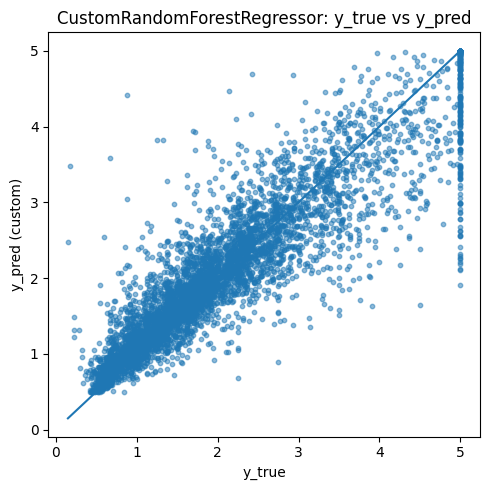

In [23]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, pred_custom, s=10, alpha=0.5)
mn = min(y_test.min(), pred_custom.min())
mx = max(y_test.max(), pred_custom.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("y_true")
plt.ylabel("y_pred (custom)")
plt.title("CustomRandomForestRegressor: y_true vs y_pred")
plt.tight_layout()
plt.show()

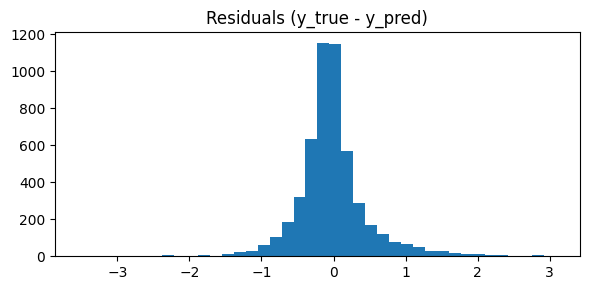

In [24]:
residuals = y_test - pred_custom
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=40)
plt.title("Residuals (y_true - y_pred)")
plt.tight_layout()
plt.show()